# 05 - Serialization Deep Dive (Pickle, Joblib, ONNX, TorchScript)

## Definition
Serialization converts in-memory model into portable byte artifact.

## Theory
Different formats optimize different goals: portability, speed, security, ecosystem support.

## Motivation
Packaging engineers must choose format intentionally, not by habit.


In [1]:
from pathlib import Path
import os

CWD = Path.cwd()
ROOT = CWD if (CWD / "pyproject.toml").exists() else CWD.parent
os.chdir(ROOT)
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".mplconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path("outputs/figures").mkdir(parents=True, exist_ok=True)
Path("outputs/benchmarks").mkdir(parents=True, exist_ok=True)


## Security Considerations
- Pickle/Joblib can execute arbitrary code when loading untrusted files
- Always verify source and checksum
- Use manifest + trusted digest allow-list in production


In [2]:
from pathlib import Path
import json

import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from ml_package.serialization_benchmark import benchmark_serialization, write_serialization_benchmark
from ml_package.model_loader import ModelLoader

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
model = RandomForestClassifier(n_estimators=250, random_state=42)
model.fit(X_train, y_train)

rows = benchmark_serialization(
    model,
    artifact_stem="notebook05_iris_model",
    output_dir="models",
)
out_path = write_serialization_benchmark(rows, "outputs/benchmarks/notebook05_serialization_benchmark.json")
print(f"Saved: {out_path}")
rows


Saved: outputs/benchmarks/notebook05_serialization_benchmark.json


[{'format': '.pkl',
  'artifact_path': 'models/notebook05_iris_model.pkl',
  'status': 'ok',
  'save_time_ms': 5.995,
  'load_time_ms': 4.006,
  'predict_time_ms': 5.033,
  'size_bytes': 387937,
  'error': None},
 {'format': '.joblib',
  'artifact_path': 'models/notebook05_iris_model.joblib',
  'status': 'ok',
  'save_time_ms': 36.389,
  'load_time_ms': 27.406,
  'predict_time_ms': 5.174,
  'size_bytes': 418497,
  'error': None},
 {'format': '.onnx',
  'artifact_path': 'models/notebook05_iris_model.onnx',
  'status': 'ok',
  'save_time_ms': 186.308,
  'load_time_ms': 22.088,
  'predict_time_ms': 0.266,
  'size_bytes': 178806,
  'error': None},
 {'format': '.pt',
  'artifact_path': 'models/notebook05_iris_model.pt',
  'status': 'error',
  'save_time_ms': None,
  'load_time_ms': None,
  'predict_time_ms': None,
  'size_bytes': None,
  'error': 'No compatible model provided for format .pt'}]

,format,artifact_path,status,save_time_ms,load_time_ms,predict_time_ms,size_bytes,error
0,.pkl,models/notebook05_iris_model.pkl,ok,5.995,4.006,5.033,387937.0,None
1,.joblib,models/notebook05_iris_model.joblib,ok,36.389,27.406,5.174,418497.0,None
2,.onnx,models/notebook05_iris_model.onnx,ok,186.308,22.088,0.266,178806.0,None
3,.pt,models/notebook05_iris_model.pt,error,NaN,NaN,NaN,NaN,No compatible model provided for format .pt


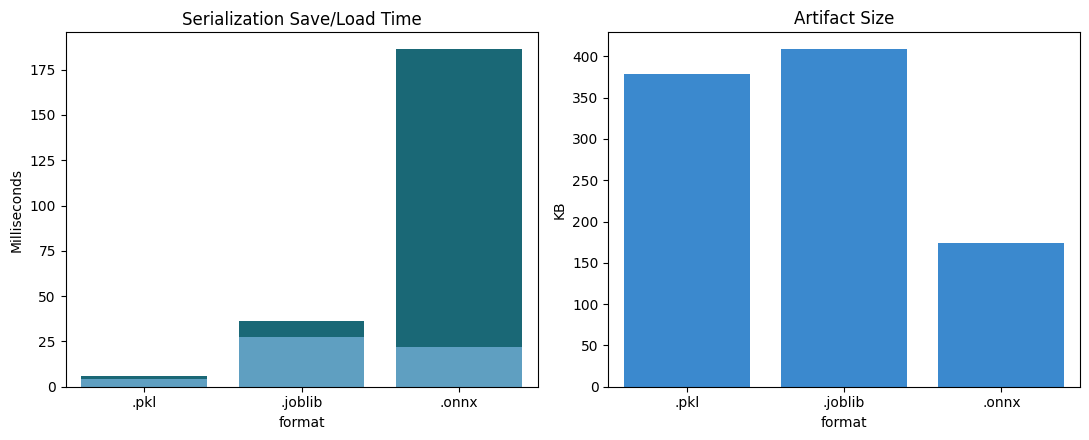

Saved: outputs/figures/notebook05_serialization_compare.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.DataFrame(rows)
display(df)

ok = df[df["status"] == "ok"]
if not ok.empty:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    sns.barplot(data=ok, x="format", y="save_time_ms", ax=axes[0], color="#0b7285")
    sns.barplot(data=ok, x="format", y="load_time_ms", ax=axes[0], color="#74c0fc", alpha=0.65)
    axes[0].set_title("Serialization Save/Load Time")
    axes[0].set_ylabel("Milliseconds")

    sns.barplot(data=ok, x="format", y=(ok["size_bytes"] / 1024), ax=axes[1], color="#228be6")
    axes[1].set_title("Artifact Size")
    axes[1].set_ylabel("KB")

    fig.tight_layout()
    fig_path = Path("outputs/figures/notebook05_serialization_compare.png")
    fig.savefig(fig_path, dpi=220, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fig_path}")


## Tradeoff Summary
- **Pickle**: simple, broad Python compatibility, higher security risk if untrusted
- **Joblib**: better for numpy-heavy objects, same trust model as pickle
- **ONNX**: portable runtime, better cross-language deployment
- **TorchScript**: strong for PyTorch workflows, not primary for sklearn pipeline
